# 3D to 1D Power Spectra

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad_vec
from field_kit import FourierAnalysis, GaussianRandomField, PowerLawBetaModel

In [2]:
# Parameters for the Gaussian random fields
l_min = 1.0  # minimum or "dissipation" scale
l_max = 200.0  # maximum or "injection" scale
alpha = -11.0 / 3.0
f_rms = 10.0  # normalization of the field

In [3]:
# Make two power spectra with different l_min values
power_spec = PowerLawBetaModel(l_min, l_max, alpha)

In [4]:
# Renormalize the power spectra to have the desired RMS value
power_spec.renormalize(f_rms)

In [5]:
# Parameters for the box and grid
le = np.array([0.0, 0.0, 0.0])
re = np.array([750.0, 750.0, 750.0])
ddims = [256] * 3
width = re - le

In [6]:
# This is a class I wrote to simplify stuff
fa = FourierAnalysis(width, ddims)

In [7]:
# This makes a Gaussian random field with the specified power spectrum
g = GaussianRandomField(le, re, ddims, power_spec, seed=20)
B = g.generate_vector_field_realization(divergence_free=True)

In [8]:
kmin = 0.0
kmax = 100.0  # a really big number to approximate infinity

def P1_int(k_perp, eta):
    k = np.sqrt(eta ** 2 + k_perp ** 2)
    term1 = 3.0*power_spec(k)*k_perp/(2.0*np.pi)
    term2 = 0.5*(1 - 0.5 * (k_perp ** 2 / (k * k)))
    return term1 * term2

eta = fa.kx[:128, 0, 0]

P_1D = quad_vec(P1_int, kmin, kmax, args=(eta,), points=(0.1, 1.0, 10.0, 30.0))[0]

In [9]:
P_3D = fa.make_powerspec(B)
P_T = 0.5*(P_3D[1]+P_3D[2])
P_1Ds = fa.integrate_kspace(P_T, axis=(1, 2)).average_symmetric_k()

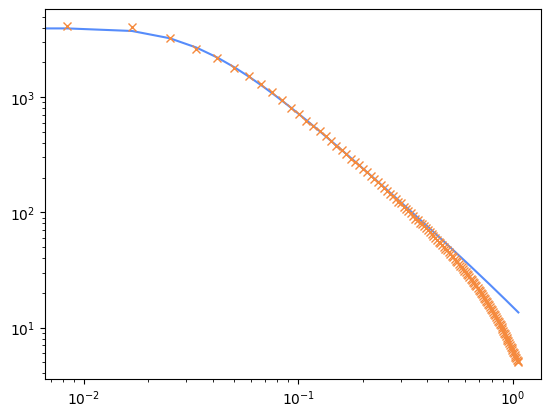

In [25]:
plt.figure()
plt.loglog(eta, P_1D, label="1D Power Spectrum")
plt.loglog(eta, P_1Ds, 'x')

In [37]:
dx = 750/256.0
Bt = np.fft.fftn(np.mean(B[1:], axis=0), axes=(0,))*dx
Bt2 = Bt*np.conj(Bt)
Bt2 = Bt2.mean(axis=(1,2))

In [57]:
N = 256
n_pos = N - N // 2
print(n_pos)
pos_indices = np.arange(n_pos)
neg_indices = (-pos_indices) % N
pos = np.take(Bt2, pos_indices)
neg = np.take(Bt2, neg_indices)

128


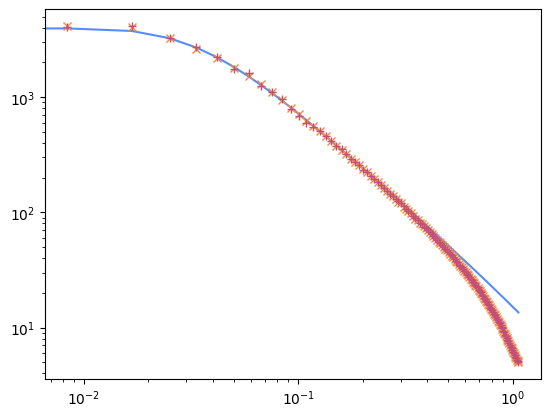

In [58]:
plt.loglog(eta, P_1D, label="1D Power Spectrum")
plt.loglog(eta, P_1Ds, 'x')
plt.loglog(eta, (pos+neg)/256/dx, '+')

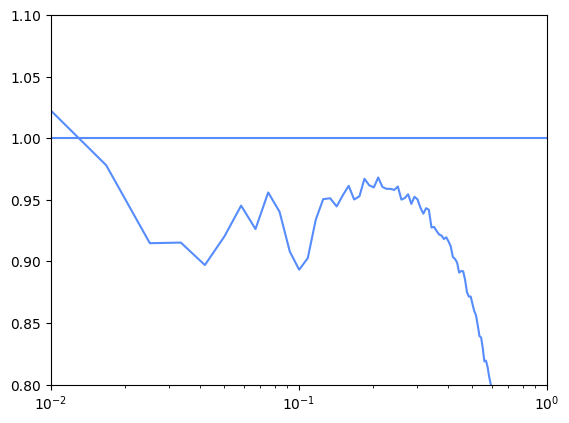

In [59]:
plt.loglog(eta, (Bt2[:128]+Bt2[128:][::-1])/256/dx/P_1D, label="1D Power Spectrum")
plt.ylim(0.8, 1.1)
plt.yscale("linear")
plt.xlim(1.0e-2, 1.0)
plt.axhline(1.0)

In [45]:
fa.kx[:, 0, 0]

array([ 0.        ,  0.00837758,  0.01675516,  0.02513274,  0.03351032,
        0.0418879 ,  0.05026548,  0.05864306,  0.06702064,  0.07539822,
        0.0837758 ,  0.09215338,  0.10053096,  0.10890855,  0.11728613,
        0.12566371,  0.13404129,  0.14241887,  0.15079645,  0.15917403,
        0.16755161,  0.17592919,  0.18430677,  0.19268435,  0.20106193,
        0.20943951,  0.21781709,  0.22619467,  0.23457225,  0.24294983,
        0.25132741,  0.25970499,  0.26808257,  0.27646015,  0.28483773,
        0.29321531,  0.30159289,  0.30997048,  0.31834806,  0.32672564,
        0.33510322,  0.3434808 ,  0.35185838,  0.36023596,  0.36861354,
        0.37699112,  0.3853687 ,  0.39374628,  0.40212386,  0.41050144,
        0.41887902,  0.4272566 ,  0.43563418,  0.44401176,  0.45238934,
        0.46076692,  0.4691445 ,  0.47752208,  0.48589966,  0.49427724,
        0.50265482,  0.5110324 ,  0.51940999,  0.52778757,  0.53616515,
        0.54454273,  0.55292031,  0.56129789,  0.56967547,  0.57